# Machine Learning Final Project

## Chronic Kidney Disease Prediction Using Machine Learning

## Course:** ISDS 7075E  
## Team Members:** Thais Diaz, Rhonda Swider, Cody Tatom 


In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

### Import the data

In [24]:
df_kd = pd.read_excel("https://github.com/rcswider/Chronic-Kidney-Disease/blob/main/data/ML_project_kidney_disease.xlsx?raw=True")
df_kd_fields = pd.read_excel("https://github.com/rcswider/Chronic-Kidney-Disease/blob/main/data/ML_project_kidney_disease.xlsx?raw=True", sheet_name = "Fields")

## DATA EXPLORATION

# Preview the Dataset

In [25]:
df_kd.head(15)

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,wc,rc,htn,dm,cad,appet,pe,ane,classification,CKD_class
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,7800,5.2,yes,yes,no,good,no,no,ckd,1
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,6000,NaN,no,no,no,good,no,no,ckd,1
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,7500,NaN,no,yes,no,poor,no,yes,ckd,1
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,6700,3.9,yes,no,no,poor,yes,yes,ckd,1
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,7300,4.6,no,no,no,good,no,no,ckd,1
5,5,60.0,90.0,1.015,3.0,0.0,NaN,NaN,notpresent,notpresent,...,7800,4.4,yes,yes,no,good,yes,no,ckd,1
6,6,68.0,70.0,1.010,0.0,0.0,NaN,normal,notpresent,notpresent,...,NaN,NaN,no,no,no,good,no,no,ckd,1
7,7,24.0,NaN,1.015,2.0,4.0,normal,abnormal,notpresent,notpresent,...,6900,5,no,yes,no,good,yes,no,ckd,1
8,8,52.0,100.0,1.015,3.0,0.0,normal,abnormal,present,notpresent,...,9600,4,yes,yes,no,good,no,yes,ckd,1
9,9,53.0,90.0,1.020,2.0,0.0,abnormal,abnormal,present,notpresent,...,12100,3.7,yes,yes,no,poor,no,yes,ckd,1


# Explore the Dataset Structure

In [26]:
df_kd.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    str    
 7   pc              335 non-null    str    
 8   pcc             396 non-null    str    
 9   ba              396 non-null    str    
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    object 
 18  r

# Sumary Statistics

In [27]:
df_kd.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,CKD_class
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,400.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,0.620000
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,0.485994
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,0.000000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,0.000000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,1.000000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,1.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,1.000000


### Investigate Data Structure/dictionary
The dta structure/dictionary from reference info on website 
shows information about the Description, Type, and value info.
This information pulls in from the second sheettab appended in the
Excel data file.

In [28]:
df_kd_fields

,Name,Description,Type,value_info
0,age,age,Integer,age in years
1,bp,blood pressure,Integer,bp in mm/Hg
2,sg,specific gravity,Categorical,"1.005,1.010,1.015,1.020,1.025"
3,al,albumin,Categorical,"0,1,2,3,4,5"
4,su,sugar,Categorical,"0,1,2,3,4,5"
5,rbc,red blood cells,Binary,"normal,abnormal"
6,pc,pus cell,Binary,"normal,abnormal"
7,pcc,pus cell clumps,Binary,"present,notpresent"
8,ba,bacteria,Binary,"present,notpresent"
9,bgr,blood gluucose random,Integer,bgr in mgs/dl


# Identify Missing Values

In [29]:
df_kd.isnull().sum()

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
CKD_class           0
dtype: int64

Most columns are missing data. Due to the limited number of records in the data, records missing data should not be removed but will be replaced based on average and mode. 

# Visualize the Target Variable: 
A visualization of the target variable was created to examine the distribution of patients with and without Chronic Kidney Disease (CKD). This step helps determine whether the dataset is balanced and provides an initial understanding of the outcome variable before model development.

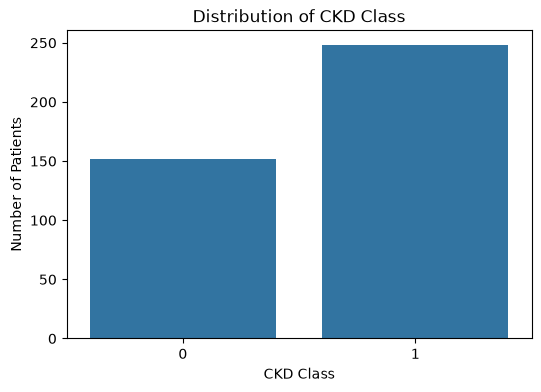

In [30]:
plt.figure(figsize=(6,4))

sns.countplot(x='CKD_class', data=df_kd)

plt.title('Distribution of CKD Class')
plt.xlabel('CKD Class')
plt.ylabel('Number of Patients')

plt.show()

# Explore Numerical Variables

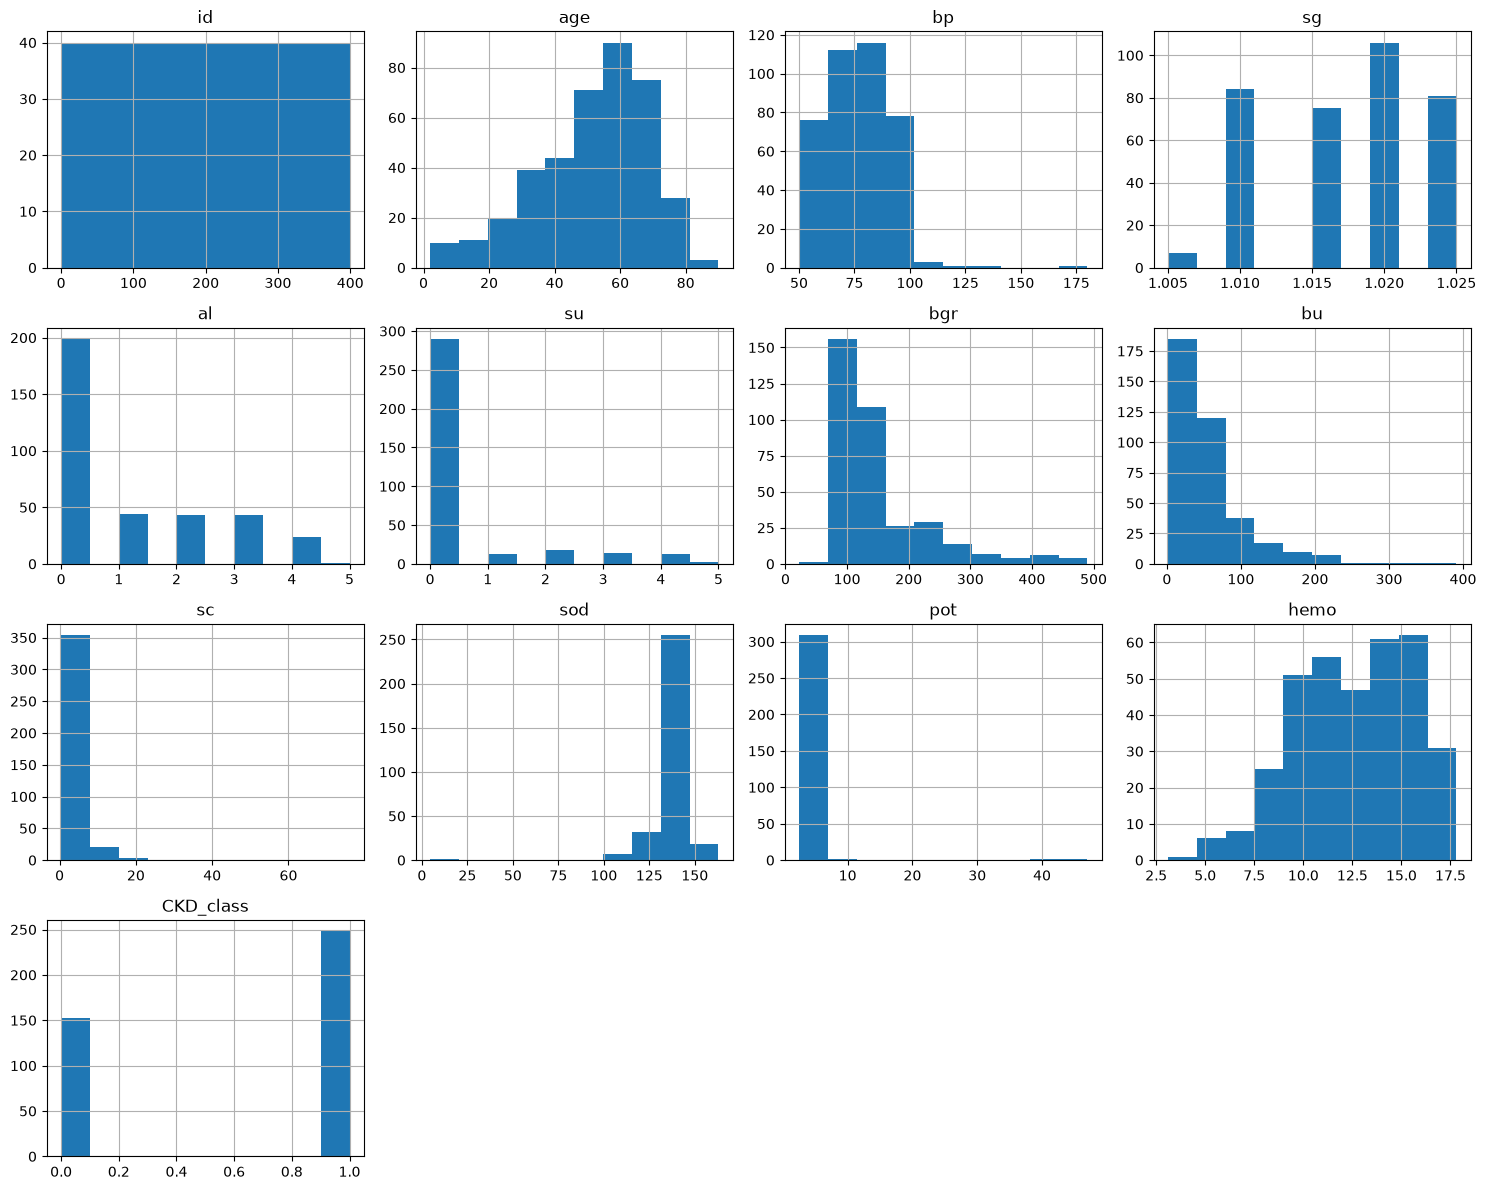

In [31]:
df_kd.hist(figsize=(15,12))

plt.tight_layout()

plt.show()

### Interpretation

The histograms provide a general view of the numerical variables in the dataset. Some features, such as blood glucose (bgr), blood urea (bu), and serum creatinine (sc), have a wider range of values, while others, such as age and hemoglobin, appear to be more evenly distributed. Reviewing these distributions helps identify patterns in the data and provides a better understanding of the dataset before moving to the data wrangling phase.

# Correlation Analysis

The correlation matrix examines the relationships between the numerical variables in the dataset. Reviewing these relationships provides additional insight into the data and helps identify features that may be important for the machine learning model.

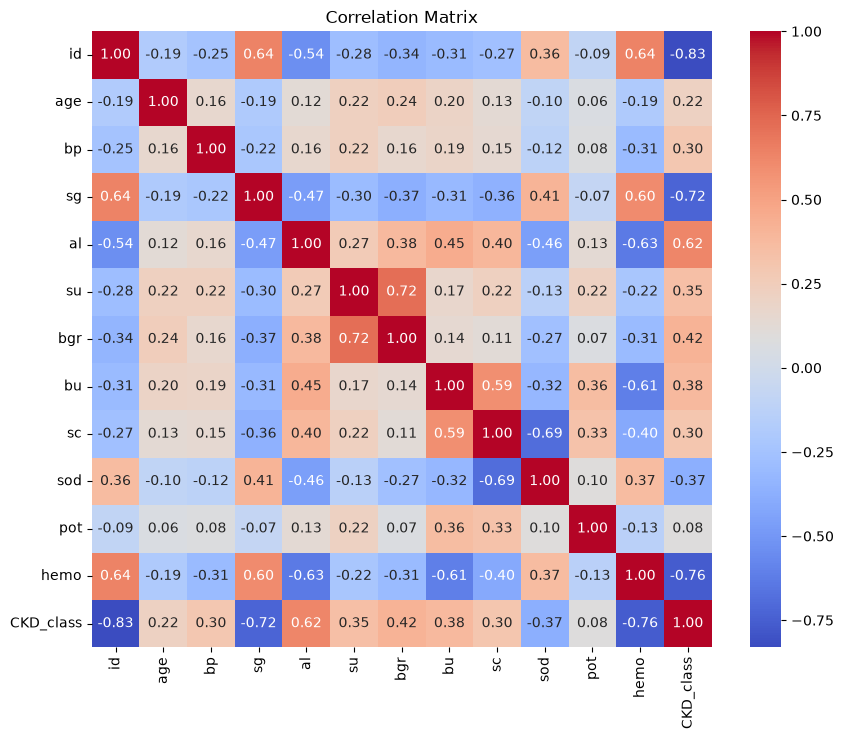

In [32]:
plt.figure(figsize=(10,8))

correlation = df_kd.corr(numeric_only=True)

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

The correlation matrix shows that several of the variables are closely related. For example, hemoglobin and packed cell volume have a strong positive correlation (0.85), while packed cell volume and red blood cell count (0.70) and hemoglobin and red blood cell count (0.68) are also strongly correlated. This supports the patterns seen in the scatter plots, where patients with CKD generally had lower values for these measurements than patients without CKD. Since these variables appear to provide similar information, future analysis may consider removing one or more of them to reduce redundancy and simplify the model. Feature selection techniques can then be used to determine which variables contribute the most to predicting chronic kidney disease.

## WRANGLE THE DATA

# Create a working copy

In [33]:
df_clean = df_kd.copy()

# Remove unnecessary columns
- ID is only an identifier, not needed to predict kidney disease
- Classification is redundant, containing the same information as CKD_Class, used in identifying where Chronic Kidney Disease was present. 

In [34]:
df_clean = df_clean.drop("id", axis=1)
df_clean = df_clean.drop("classification", axis=1)

# Adjust for bad values and convert data types

In [35]:
df_clean = df_clean.replace("\t", "", regex=True)
df_clean = df_clean.replace(" ", "", regex=True)
df_clean.replace("?", np.nan, inplace = True)
df_clean[["wc", "pcv", "rc"]] = df_clean[["wc", "pcv", "rc"]].astype("float64")

Some data points were found with tabs or spaces. These were causing some numeric figures to return as strings, while some values such as "yes" and "no" were returning as separate values rather than grouped with their respective values. 

# Adjust for Missing Values

In [36]:
# Impute missing variables

df_clean['age'] = df_clean.age.fillna(df_clean.age.median())
df_clean['bp'] = df_clean.bp.fillna(df_clean.bp.mean())
df_clean['bgr'] = df_clean.bgr.fillna(df_clean.bgr.mean())
df_clean['bu'] = df_clean.bu.fillna(df_clean.bu.mean())
df_clean['sc'] = df_clean.sc.fillna(df_clean.sc.mean())
df_clean['sod'] = df_clean.sod.fillna(df_clean.sod.mean())
df_clean['pot'] = df_clean.pot.fillna(df_clean.pot.mean())
df_clean['hemo'] = df_clean.hemo.fillna(df_clean.hemo.mean())
df_clean['pcv'] = df_clean.pcv.fillna(df_clean.pcv.mean())
df_clean['wc'] = df_clean.wc.fillna(df_clean.wc.mean())
df_clean['rc'] = df_clean.rc.fillna(df_clean.rc.mean())

df_clean['sg'] = df_clean.sg.fillna(df_clean.sg.mode()[0])
df_clean['al'] = df_clean.al.fillna(df_clean.al.mode()[0])
df_clean['su'] = df_clean.su.fillna(df_clean.su.mode()[0])
df_clean['rbc'] = df_clean.rbc.fillna(df_clean.rbc.mode()[0])
df_clean['pc'] = df_clean.pc.fillna(df_clean.pc.mode()[0])
df_clean['pcc'] = df_clean.pcc.fillna(df_clean.pcc.mode()[0])
df_clean['ba'] = df_clean.ba.fillna(df_clean.ba.mode()[0])
df_clean['htn'] = df_clean.htn.fillna(df_clean.htn.mode()[0])
df_clean['dm'] = df_clean.dm.fillna(df_clean.dm.mode()[0])
df_clean['cad'] = df_clean.cad.fillna(df_clean.cad.mode()[0])
df_clean['appet'] = df_clean.appet.fillna(df_clean.appet.mode()[0])
df_clean['pe'] = df_clean.pe.fillna(df_clean.pe.mode()[0])
df_clean['ane'] = df_clean.ane.fillna(df_clean.ane.mode()[0])


### Recheck data info to make sure all missing items are clean

In [37]:
df_clean.info()  

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        400 non-null    float64
 1   bp         400 non-null    float64
 2   sg         400 non-null    float64
 3   al         400 non-null    float64
 4   su         400 non-null    float64
 5   rbc        400 non-null    str    
 6   pc         400 non-null    str    
 7   pcc        400 non-null    str    
 8   ba         400 non-null    str    
 9   bgr        400 non-null    float64
 10  bu         400 non-null    float64
 11  sc         400 non-null    float64
 12  sod        400 non-null    float64
 13  pot        400 non-null    float64
 14  hemo       400 non-null    float64
 15  pcv        400 non-null    float64
 16  wc         400 non-null    float64
 17  rc         400 non-null    float64
 18  htn        400 non-null    str    
 19  dm         400 non-null    str    
 20  cad        400 non-nu

# Normalization

In [38]:
# replace (original value) by (original value)/(maximum value)
df_clean['wc'] = df_clean['wc']/df_clean['wc'].max()

The White Blood Cell Count (wc) variable had multiple high values and a wide range. This variable was normalized to scale the values down for visualization while maintaining the integrity of the data. 

# Binning


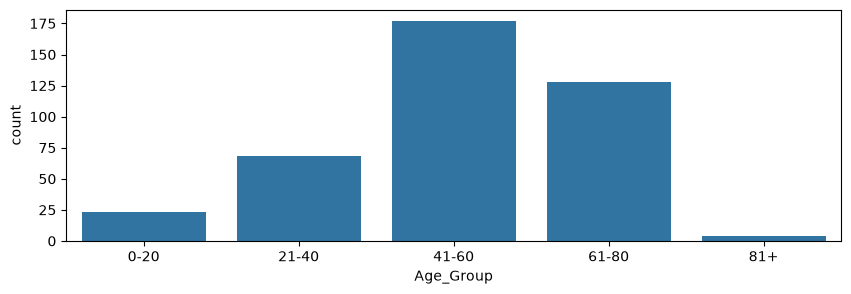

In [39]:
# Binning the age variable
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20', '21-40', '41-60', '61-80', '81+']

df_clean['Age_Group'] = pd.cut(
    df_clean['age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

plt.figure(figsize=(10,3))
sns.countplot(x=df_clean['Age_Group'])
plt.show()

# Separate the Features and target variable
The dataset contains two columns that identify whether a patient has chronic kidney disease: `classification` and `CKD_class`. Since both columns represent the same diagnosis, `CKD_class` is used as the target variable because it is already coded as 0 and 1. The `classification` column is removed from the input features to avoid including duplicate information when building the machine learning model.

In [40]:
X = df_clean.drop("CKD_class", axis=1)

y = df_clean["CKD_class"]

# Create the training and testing datasets

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [42]:
print(X_train.shape)
print(X_test.shape)

(320, 25)
(80, 25)


PROJECT PART 1 - SUMMARY

The dataset has been explored and prepared by creating a working copy, removing unnecessary columns, selecting the target variable, filling for missing data, and creating the training and testing datasets. The remaining preprocessing steps include converting categorical variables into numeric values before building and evaluating the machine learning model.